# SPARTAN & IMPROVE — an orientation

A first look at the two filter networks we are bridging, for someone who has
**not seen the data yet**. Three parts:

1. **SPARTAN on its own** — what it is, where its sites are, what it measures, how much data.
2. **IMPROVE on its own** — the same orientation for the US IMPROVE network.
3. **Where they meet** — the quantities both networks carry, shown as side-by-side
   distributions and cross-plots (the networks share no sites/dates, so the comparison
   is distributional + relationship-based, not a row-level join).

Re-run top to bottom to regenerate every figure and table under
`research/spartan/orientation/`.

## 0. Setup

In [1]:
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)


def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "AGENTS.md").exists() and (cand / "research").exists():
            return cand
    raise RuntimeError("Could not locate repo root (AGENTS.md). CWD=%s" % Path.cwd())


REPO_ROOT = find_repo_root()
print("Repo root:", REPO_ROOT)

sys.path.insert(0, str(REPO_ROOT / "research/ftir_hips_chem/scripts"))
try:
    from plotting import apply_default_style
    from plotting.utils import calculate_regression_stats
    apply_default_style()
    print("Applied plotting.apply_default_style()")
except Exception as e:
    print("plotting package unavailable (%s); using local fallbacks" % e)

    def calculate_regression_stats(x, y):
        x = np.asarray(x, float); y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 3:
            return None
        slope, intercept = np.polyfit(x, y, 1)
        r = np.corrcoef(x, y)[0, 1]
        return {"n": len(x), "slope": slope, "intercept": intercept,
                "r_squared": r ** 2, "correlation": r}

# Paths
SPARTAN_PKL = REPO_ROOT / "research/ftir_hips_chem/Filter Data/unified_filter_dataset.pkl"
IMPROVE_CSV = REPO_ROOT / "research/ftir_hips_chem/output/improve_high_fabs_comparison/improve_valid_cleaned.csv"
INV = REPO_ROOT / "research/spartan/inventory"   # full-network SPARTAN inventory CSVs

OUT = REPO_ROOT / "research/spartan/orientation"
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

NET_COLORS = {"SPARTAN": "#C0392B", "IMPROVE": "#2E86C1"}

# The shared schema: harmonized column -> (pretty label, unit, log-scale?)
SHARED = {
    "EC_ugm3":   ("Elemental Carbon", "µg/m³", True),
    "OC_ugm3":   ("Organic Carbon",   "µg/m³", True),
    "Fabs_Mm":   ("Absorption fAbs",  "Mm⁻¹",  True),
    "Fe_ugm3":   ("Iron",             "µg/m³", True),
    "PM25_ugm3": ("Fine PM₂.₅ mass",  "µg/m³", True),
}
SCATTER_SAMPLE = 6000
print("Figures ->", FIG_DIR)
print("Tables  ->", TAB_DIR)

Repo root: /Users/ahmadjalil/github/aethmodular
Applied plotting.apply_default_style()
Figures -> /Users/ahmadjalil/github/aethmodular/research/spartan/orientation/figures
Tables  -> /Users/ahmadjalil/github/aethmodular/research/spartan/orientation/tables


## 1. SPARTAN at a glance

**SPARTAN** (Surface PARTiculate mAtter Network) is a global network of ground
filter samplers, deliberately sited in **under-monitored, often high-pollution**
cities to ground-truth satellite PM₂.₅. Each station runs a filter sampler on a
nominal **1-in-9-day** cadence plus a co-located nephelometer.

The numbers below come from our full-network inventory
(`research/spartan/inventory/`), which crawled the entire public SPARTAN FTP.

In [2]:
# Full-network SPARTAN picture from the inventory crawl
site_loc = pd.read_csv(INV / "site_locations.csv")
top = pd.read_csv(INV / "top_sites.csv")
overview = pd.read_csv(INV / "overview.csv")

sp_sites = top.merge(site_loc, on="site", how="left")

print(f"SPARTAN public network:")
print(f"  sites (public FTP)      : {top['site'].nunique()}")
print(f"  total filter+nephel rows: {int(top['total_samples'].sum()):,}")
_dmin = pd.to_datetime(overview['date_min'], errors='coerce')
_dmax = pd.to_datetime(overview['date_max'], errors='coerce')
# drop the known ILNZ year-2166/2167 typo rows (see inventory README caveat)
_dmax = _dmax[_dmax.dt.year <= 2030]
print(f"  date range              : {_dmin.min().date()} -> {_dmax.max().date()}")
print(f"  products / subproducts  : {overview['product'].nunique()} products, {overview['subproduct'].nunique()} subproducts")
print()
print("Top 10 sites by coverage score (breadth x completeness):")
print(top.sort_values('score', ascending=False)
        .head(10)[['site','n_subproducts','total_samples','score','earliest','latest']]
        .to_string(index=False))

SPARTAN public network:
  sites (public FTP)      : 37
  total filter+nephel rows: 739,864
  date range              : 2013-06-28 -> 2026-04-26
  products / subproducts  : 3 products, 9 subproducts

Top 10 sites by coverage score (breadth x completeness):
site  n_subproducts  total_samples  score   earliest     latest
CADO              9        48209.0   78.0 2017-07-10 2019-09-05
AUMN              9        48607.0   75.2 2022-07-21 2026-02-27
USNO              9        35959.0   68.5 2022-08-03 2024-11-25
CASH              9       145361.0   61.7 2017-04-25 2024-11-25
KRUL              9        21283.0   59.3 2021-09-03 2026-03-04
CHTS              9        66906.0   56.8 2013-06-28 2024-10-06
SGSU              9        42748.0   55.0 2015-07-10 2020-01-28
MXMC              9        34301.0   50.2 2021-02-17 2026-02-23
CALE              9        21120.0   44.8 2017-08-26 2019-09-09
AEAZ              9        44794.0   44.2 2019-04-26 2024-12-02


cartopy unavailable (No module named 'cartopy'); plain lon/lat scatter


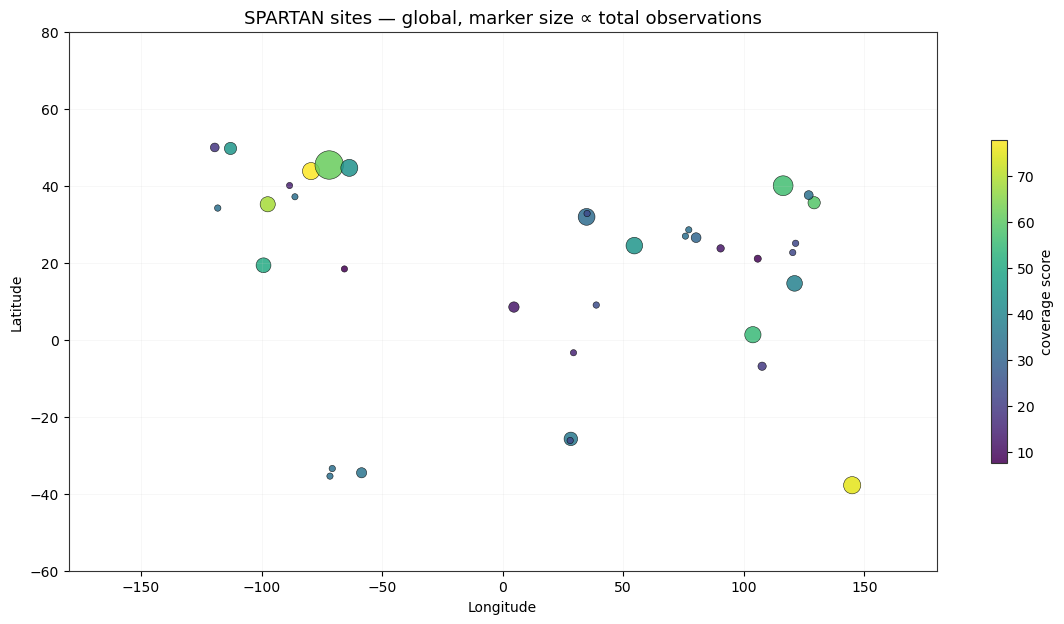

In [3]:
# World map of SPARTAN sites — size ∝ observations, colour = coverage score
m = sp_sites.dropna(subset=["lat", "lon"]).copy()
fig, ax = plt.subplots(figsize=(14, 7))
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#EEEEEE")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2, edgecolor="#BBBBBB")
    tx = ccrs.PlateCarree()
    sc = ax.scatter(m["lon"], m["lat"], transform=tx,
                    s=20 + m["total_samples"] / m["total_samples"].max() * 400,
                    c=m["score"], cmap="viridis", alpha=0.85, edgecolors="k", linewidths=0.4)
except Exception as e:
    print("cartopy unavailable (%s); plain lon/lat scatter" % e)
    sc = ax.scatter(m["lon"], m["lat"],
                    s=20 + m["total_samples"] / m["total_samples"].max() * 400,
                    c=m["score"], cmap="viridis", alpha=0.85, edgecolors="k", linewidths=0.4)
    ax.set_xlim(-180, 180); ax.set_ylim(-60, 80)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=0.2)
plt.colorbar(sc, ax=ax, shrink=0.6, label="coverage score")
ax.set_title("SPARTAN sites — global, marker size ∝ total observations", fontsize=13)
fig.savefig(FIG_DIR / "fig_spartan_map.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# What SPARTAN measures — the public product structure
prod = (overview[overview['rows'] > 0]
        .groupby(['product', 'subproduct'])
        .agg(sites=('site', 'nunique'), rows=('rows', 'sum'))
        .reset_index())
print(prod.to_string(index=False))
print()
print("For the cross-network comparison (Section 3) we only use the filter chemistry")
print("that IMPROVE also reports: EC, OC, optical absorption (HIPS fAbs), Fe, PM2.5 mass.")

    product    subproduct  sites   rows
FilterBased  ChemSpecPM10     27   9079
FilterBased  ChemSpecPM25     36 151112
FilterBased  ReconstrPM25     36  47831
NephelProcd  DailyScaPM10     20  12535
NephelProcd  DailyScaPM25     20  10742
NephelProcd HourlyScaPM10     20 240595
NephelProcd HourlyScaPM25     20 225724
TimeResPM25  DailyEstPM25     21  12636
TimeResPM25 HourlyEstPM25     21 229046

For the cross-network comparison (Section 3) we only use the filter chemistry
that IMPROVE also reports: EC, OC, optical absorption (HIPS fAbs), Fe, PM2.5 mass.


## 2. IMPROVE at a glance

**IMPROVE** (Interagency Monitoring of PROtected Visual Environments) is the US
long-term aerosol network, running since the late 1980s, mostly in national parks
and wilderness (Class I visibility areas) on a **1-in-3-day** cadence. It is the
reference network for the chemistry we care about: thermal-optical **EC/OC**,
**fAbs** (HIPS, post-2017), the **Fe/Soil** crustal panel, and gravimetric **PM₂.₅ mass**.

The frame below is the pull we pre-cleaned for this work
(`improve_valid_cleaned.csv`).

In [5]:
# Load IMPROVE once, carrying the metadata we need for the map + the harmonized values
imp_cols = ["SiteCode", "Date", "ECf_Val", "OCf_Val", "fAbs_Val", "FEf_Val",
            "MF_Val", "SOILf_Val", "SiteName", "Country", "State", "Latitude", "Longitude"]
imp = pd.read_csv(IMPROVE_CSV, usecols=lambda c: c in set(imp_cols),
                  parse_dates=["Date"], low_memory=False)

print("IMPROVE pull:")
print(f"  filter rows : {len(imp):,}")
print(f"  sites       : {imp['SiteCode'].nunique()}")
print(f"  date range  : {imp['Date'].min().date()} -> {imp['Date'].max().date()}")
print(f"  countries   : {sorted(imp['Country'].dropna().unique())}")

IMPROVE pull:
  filter rows : 379,697
  sites       : 214
  date range  : 2003-01-03 -> 2025-07-30
  countries   : ['CA', 'KR', 'US']


cartopy unavailable (No module named 'cartopy'); plain lon/lat scatter


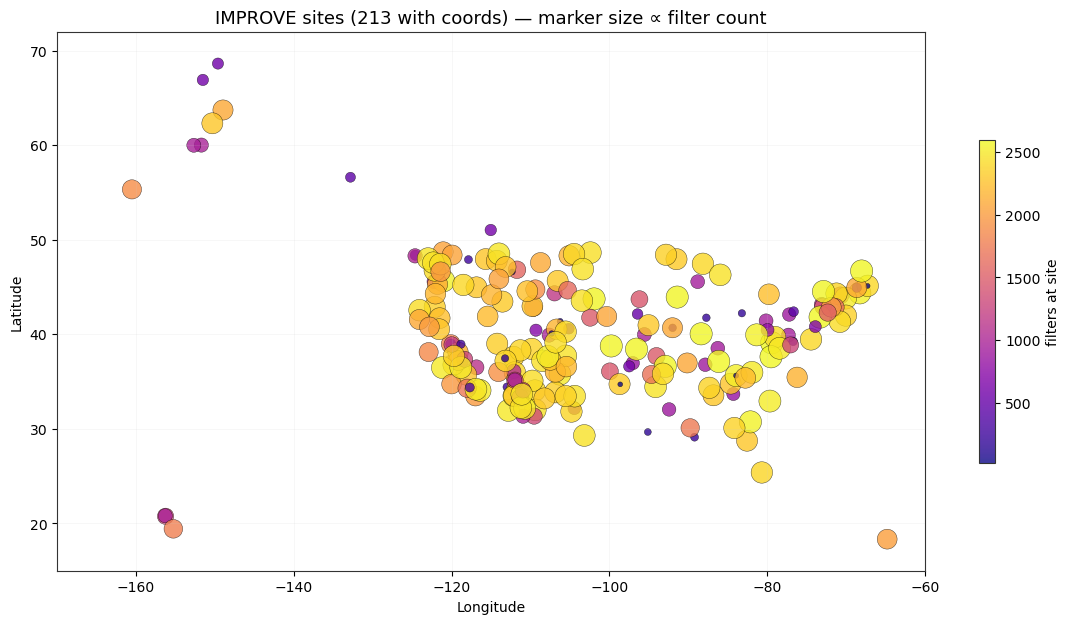

In [6]:
# Map of IMPROVE sites — US-centric, size ∝ filters at that site
site_n = (imp.groupby(["SiteCode", "SiteName", "Latitude", "Longitude"])
             .size().rename("n").reset_index().dropna(subset=["Latitude", "Longitude"]))
fig, ax = plt.subplots(figsize=(14, 7))
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-170, -60, 15, 72], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#EEEEEE")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.2, edgecolor="#CCCCCC")
    tx = ccrs.PlateCarree()
    sc = ax.scatter(site_n["Longitude"], site_n["Latitude"], transform=tx,
                    s=10 + site_n["n"] / site_n["n"].max() * 250,
                    c=site_n["n"], cmap="plasma", alpha=0.8, edgecolors="k", linewidths=0.3)
except Exception as e:
    print("cartopy unavailable (%s); plain lon/lat scatter" % e)
    sc = ax.scatter(site_n["Longitude"], site_n["Latitude"],
                    s=10 + site_n["n"] / site_n["n"].max() * 250,
                    c=site_n["n"], cmap="plasma", alpha=0.8, edgecolors="k", linewidths=0.3)
    ax.set_xlim(-170, -60); ax.set_ylim(15, 72)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=0.2)
plt.colorbar(sc, ax=ax, shrink=0.6, label="filters at site")
ax.set_title(f"IMPROVE sites ({len(site_n)} with coords) — marker size ∝ filter count", fontsize=13)
fig.savefig(FIG_DIR / "fig_improve_map.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
# What IMPROVE measures here — per-parameter coverage of the pull
imp_params = {"ECf_Val": "Elemental Carbon (µg/m³)", "OCf_Val": "Organic Carbon (µg/m³)",
              "fAbs_Val": "Absorption fAbs (Mm⁻¹)", "FEf_Val": "Iron (µg/m³)",
              "SOILf_Val": "Soil (µg/m³)", "MF_Val": "Fine PM₂.₅ mass (µg/m³)"}
rows = []
for col, label in imp_params.items():
    s = imp[col].dropna()
    rows.append({"parameter": label, "n_filters": len(s),
                 "n_sites": imp.loc[s.index, "SiteCode"].nunique(),
                 "median": round(float(s.median()), 4),
                 "p05": round(float(s.quantile(0.05)), 4),
                 "p95": round(float(s.quantile(0.95)), 4)})
imp_param_cov = pd.DataFrame(rows)
imp_param_cov.to_csv(TAB_DIR / "improve_parameter_coverage.csv", index=False)
imp_param_cov

,parameter,n_filters,n_sites,median,p05,p95
0,Elemental Carbon (µg/m³),379697,214,0.1213,0.0166,0.6215
1,Organic Carbon (µg/m³),379697,214,0.6778,0.1128,2.8673
2,Absorption fAbs (Mm⁻¹),379697,214,1.5102,0.1900,6.3800
3,Iron (µg/m³),379658,214,0.0223,0.0022,0.1468
4,Soil (µg/m³),379606,214,0.3291,0.0322,2.2696
5,Fine PM₂.₅ mass (µg/m³),379367,213,3.4786,0.7060,12.8742


## 3. Where they meet — the shared data

Now we put them side by side, using **only the quantities both networks carry**:
EC, OC, fAbs, Fe, and PM₂.₅ mass, plus the derived ratios OC/EC, fAbs/EC (≈ MAC),
and Fe/PM₂.₅.

> **EC caveat.** SPARTAN stores two non-overlapping filter sets — a *ChemSpec* set
> (thermal EC/OC, metals, mass) and an *FTIR/HIPS* set (`EC_ftir`, `HIPS_Fabs`).
> `HIPS_Fabs` only co-occurs with `EC_ftir`. So distributions / OC-EC use thermal
> `ChemSpec_EC`; the fAbs–EC and MAC analyses use FTIR `EC_ftir`. Read the MAC slope
> with that FTIR-vs-thermal difference in mind.

The SPARTAN side of this comparison is the **4-site FTIR/HIPS subset** in the unified
pickle (not the full 40-site network shown in Section 1).

In [8]:
# --- SPARTAN: long -> wide -> harmonized (the FTIR/HIPS subset) ---
sp_long = pd.read_pickle(SPARTAN_PKL)
sp_long["SampleDate"] = pd.to_datetime(sp_long["SampleDate"], errors="coerce")

sp_params = ["ChemSpec_EC_PM2.5", "ChemSpec_OC_PM2.5", "HIPS_Fabs", "EC_ftir",
             "ChemSpec_Iron_PM2.5", "ChemSpec_Filter_PM2.5_mass"]
sp_wide = (sp_long[sp_long["Parameter"].isin(sp_params)]
           .pivot_table(index=["Site", "FilterId", "SampleDate"],
                        columns="Parameter", values="Concentration", aggfunc="first")
           .reset_index())

spartan = pd.DataFrame({
    "network": "SPARTAN", "site": sp_wide["Site"], "date": sp_wide["SampleDate"],
    "EC_ugm3": sp_wide.get("ChemSpec_EC_PM2.5"),
    "OC_ugm3": sp_wide.get("ChemSpec_OC_PM2.5"),
    "Fabs_Mm": sp_wide.get("HIPS_Fabs"),
    "EC_ftir_ugm3": sp_wide.get("EC_ftir"),
    "Fe_ugm3": sp_wide.get("ChemSpec_Iron_PM2.5") / 1000.0,
    "PM25_ugm3": sp_wide.get("ChemSpec_Filter_PM2.5_mass"),
})

# --- IMPROVE: harmonize from the frame loaded in Section 2 ---
improve = pd.DataFrame({
    "network": "IMPROVE", "site": imp["SiteCode"], "date": imp["Date"],
    "EC_ugm3": imp["ECf_Val"], "OC_ugm3": imp["OCf_Val"], "Fabs_Mm": imp["fAbs_Val"],
    "EC_ftir_ugm3": imp["ECf_Val"], "Fe_ugm3": imp["FEf_Val"], "PM25_ugm3": imp["MF_Val"],
})

both = pd.concat([spartan, improve], ignore_index=True)
ec_ok = both["EC_ugm3"] > 0; pm_ok = both["PM25_ugm3"] > 0; ecf_ok = both["EC_ftir_ugm3"] > 0
both["OC_EC"]   = np.where(ec_ok, both["OC_ugm3"] / both["EC_ugm3"], np.nan)
both["Fabs_EC"] = np.where(ecf_ok, both["Fabs_Mm"] / both["EC_ftir_ugm3"], np.nan)
both["Fe_PM"]   = np.where(pm_ok, 100 * both["Fe_ugm3"] / both["PM25_ugm3"], np.nan)
print(both.groupby("network").size().rename("rows").to_string())

network
IMPROVE    379697
SPARTAN      1450


In [9]:
# Coverage of the shared parameters, per network
cov = []
for net, g in both.groupby("network"):
    for col, (label, unit, _) in SHARED.items():
        s = g[col].dropna()
        d = g.loc[s.index, "date"]
        cov.append({"network": net, "quantity": label, "units": unit,
                    "n": int(s.shape[0]), "n_sites": g.loc[s.index, "site"].nunique(),
                    "date_min": d.min(), "date_max": d.max(),
                    "median": round(float(s.median()), 4) if len(s) else np.nan})
coverage = pd.DataFrame(cov)
coverage.to_csv(TAB_DIR / "shared_coverage_summary.csv", index=False)
coverage

,network,quantity,units,n,n_sites,date_min,date_max,median
0,IMPROVE,Elemental Carbon,µg/m³,379697,214,2003-01-03,2025-07-30,0.1213
1,IMPROVE,Organic Carbon,µg/m³,379697,214,2003-01-03,2025-07-30,0.6778
2,IMPROVE,Absorption fAbs,Mm⁻¹,379697,214,2003-01-03,2025-07-30,1.5102
3,IMPROVE,Iron,µg/m³,379658,214,2003-01-03,2025-07-30,0.0223
4,IMPROVE,Fine PM₂.₅ mass,µg/m³,379367,213,2003-01-03,2025-07-30,3.4786
5,SPARTAN,Elemental Carbon,µg/m³,543,4,2019-05-08,2024-10-06,1.5300
6,SPARTAN,Organic Carbon,µg/m³,543,4,2019-05-08,2024-10-06,3.6800
7,SPARTAN,Absorption fAbs,Mm⁻¹,546,4,2022-07-05,2024-12-08,18.6188
8,SPARTAN,Iron,µg/m³,819,4,2013-09-10,2024-10-06,0.2369
9,SPARTAN,Fine PM₂.₅ mass,µg/m³,853,4,2013-06-28,2024-10-06,17.3300


### 3a. Distributions — how dirty is each network's air?

SPARTAN sits in polluted megacities; IMPROVE sits in pristine US parks. Expect the
SPARTAN distributions to sit well above IMPROVE on every concentration axis.

/tmp/claude-501/ipykernel_34028/3603689494.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/tmp/claude-501/ipykernel_34028/3603689494.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/tmp/claude-501/ipykernel_34028/3603689494.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/tmp/claude-501/ipykernel_34028/3603689494.py:11: MatplotlibDeprecationWarning:

/tmp/claude-501/ipykernel_34028/3603689494.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)


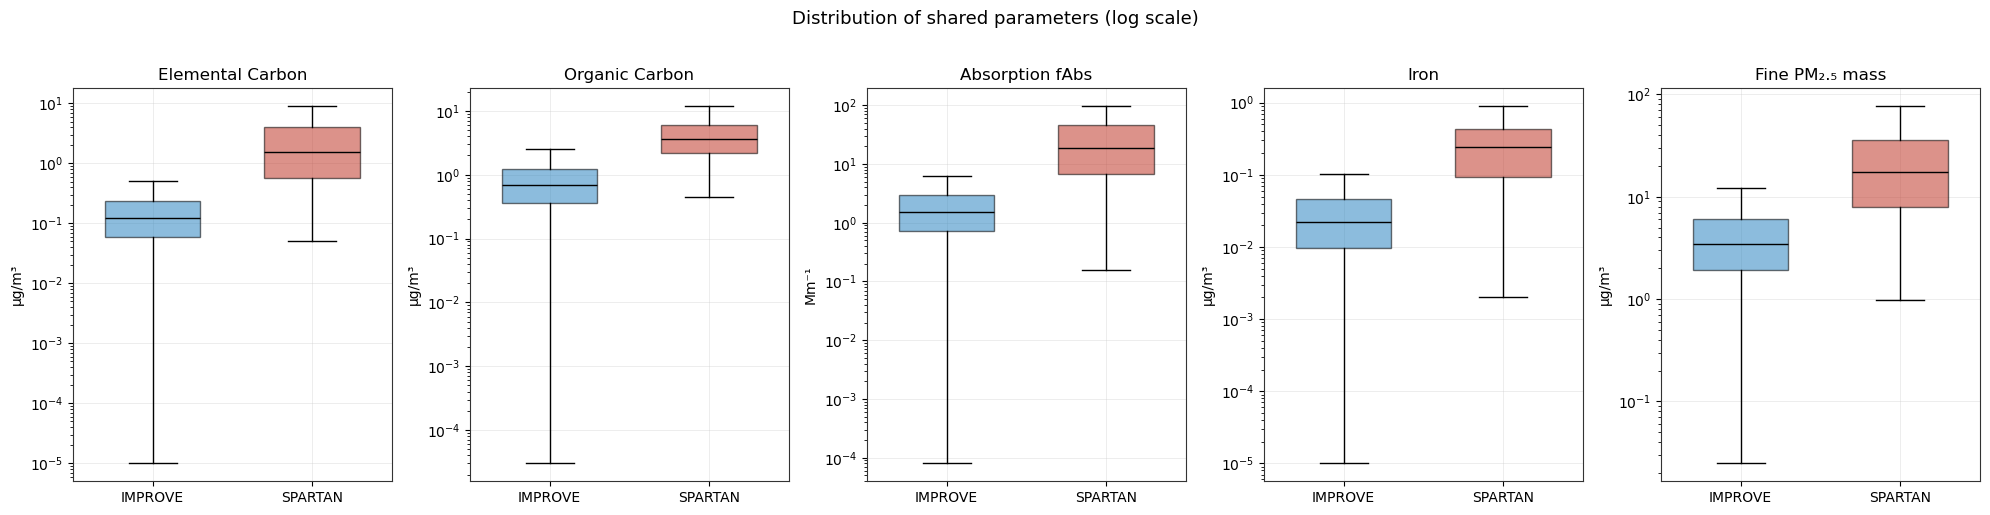

In [10]:
def _pos(s):
    return s[np.isfinite(s) & (s > 0)]

fig, axes = plt.subplots(1, len(SHARED), figsize=(4 * len(SHARED), 5))
for ax, (col, (label, unit, logy)) in zip(axes, SHARED.items()):
    data, labels, colors = [], [], []
    for net in ["IMPROVE", "SPARTAN"]:
        vals = _pos(both.loc[both.network == net, col])
        if len(vals):
            data.append(vals.values); labels.append(net); colors.append(NET_COLORS[net])
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_yscale("log"); ax.set_title(label); ax.set_ylabel(unit)
fig.suptitle("Distribution of shared parameters (log scale)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### 3b. Cross-plots — do the relationships agree?

Even though the networks never share a filter, the *relationships* between quantities
are physically meaningful and comparable: absorption vs EC (slope ≈ effective **MAC**),
OC vs EC (combustion signature), and Fe vs PM₂.₅ (crustal fraction).

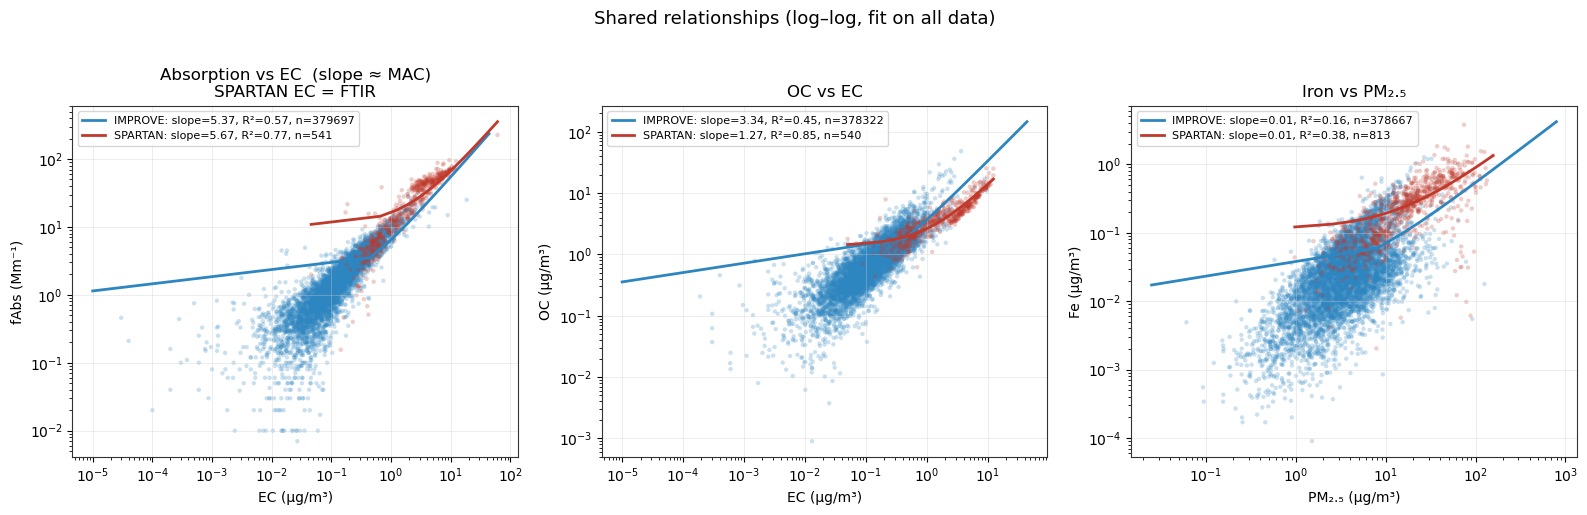

,relationship,network,n,slope,intercept,r_squared,correlation
0,Fabs_Mm~EC_ftir_ugm3,IMPROVE,379697,5.3674,1.1418,0.5673,0.7532
1,Fabs_Mm~EC_ftir_ugm3,SPARTAN,541,5.6700,10.6393,0.7726,0.8790
2,OC_ugm3~EC_ugm3,IMPROVE,378322,3.3366,0.3561,0.4484,0.6697
3,OC_ugm3~EC_ugm3,SPARTAN,540,1.2653,1.3826,0.8494,0.9216
4,Fe_ugm3~PM25_ugm3,IMPROVE,378667,0.0053,0.0171,0.1626,0.4032
5,Fe_ugm3~PM25_ugm3,SPARTAN,813,0.0078,0.1138,0.3846,0.6202


In [11]:
def scatter_fit(ax, xcol, ycol, xlabel, ylabel, log=True):
    fits = []
    for net in ["IMPROVE", "SPARTAN"]:
        g = both[both.network == net][[xcol, ycol]].dropna()
        if log:
            g = g[(g[xcol] > 0) & (g[ycol] > 0)]
        if len(g) < 3:
            continue
        st = calculate_regression_stats(g[xcol].values, g[ycol].values)
        gp = g.sample(min(SCATTER_SAMPLE, len(g)), random_state=0)
        ax.scatter(gp[xcol], gp[ycol], s=10, alpha=0.25, color=NET_COLORS[net], edgecolors="none")
        xs = np.linspace(g[xcol].min(), g[xcol].max(), 100)
        ax.plot(xs, st["slope"] * xs + st["intercept"], color=NET_COLORS[net], lw=2,
                label=f"{net}: slope={st['slope']:.2f}, R²={st['r_squared']:.2f}, n={st['n']}")
        fits.append({"relationship": f"{ycol}~{xcol}", "network": net, **st})
    if log:
        ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.legend(fontsize=8)
    return fits

all_fits = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
all_fits += scatter_fit(axes[0], "EC_ftir_ugm3", "Fabs_Mm", "EC (µg/m³)", "fAbs (Mm⁻¹)")
axes[0].set_title("Absorption vs EC  (slope ≈ MAC)\nSPARTAN EC = FTIR")
all_fits += scatter_fit(axes[1], "EC_ugm3", "OC_ugm3", "EC (µg/m³)", "OC (µg/m³)")
axes[1].set_title("OC vs EC")
all_fits += scatter_fit(axes[2], "PM25_ugm3", "Fe_ugm3", "PM₂.₅ (µg/m³)", "Fe (µg/m³)")
axes[2].set_title("Iron vs PM₂.₅")
fig.suptitle("Shared relationships (log–log, fit on all data)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_cross_plots.png", dpi=120, bbox_inches="tight")
plt.show()

rel_fits = pd.DataFrame(all_fits)[["relationship", "network", "n", "slope",
                                   "intercept", "r_squared", "correlation"]].round(4)
rel_fits.to_csv(TAB_DIR / "relationship_fits.csv", index=False)
rel_fits

### 3c. Derived ratios

Ratios normalise away the concentration gap and isolate composition: **OC/EC**
(source mix), **fAbs/EC ≈ MAC** (how absorbing the black carbon is), and **Fe/PM₂.₅**
(crustal/dust fraction).

/tmp/claude-501/ipykernel_34028/1244939911.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/tmp/claude-501/ipykernel_34028/1244939911.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
/tmp/claude-501/ipykernel_34028/1244939911.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)


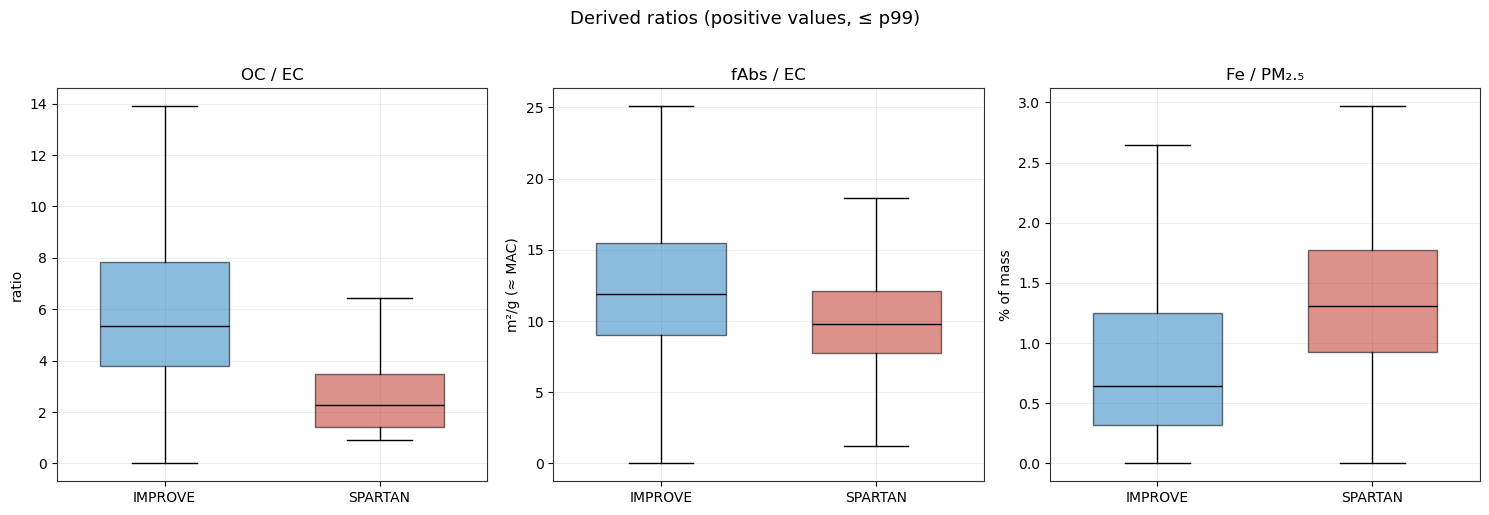

,network,ratio,unit,n,median,p25,p75
0,IMPROVE,OC / EC,ratio,374525,5.348,3.774,7.825
1,SPARTAN,OC / EC,ratio,534,2.267,1.406,3.472
2,IMPROVE,fAbs / EC,m²/g (≈ MAC),375900,11.906,9.018,15.446
3,SPARTAN,fAbs / EC,m²/g (≈ MAC),535,9.790,7.732,12.108
4,IMPROVE,Fe / PM₂.₅,% of mass,374875,0.641,0.322,1.253
5,SPARTAN,Fe / PM₂.₅,% of mass,804,1.306,0.927,1.770


In [12]:
ratios = {"OC_EC": ("OC / EC", "ratio"), "Fabs_EC": ("fAbs / EC", "m²/g (≈ MAC)"),
          "Fe_PM": ("Fe / PM₂.₅", "% of mass")}
fig, axes = plt.subplots(1, len(ratios), figsize=(5 * len(ratios), 5))
rows = []
for ax, (col, (label, unit)) in zip(axes, ratios.items()):
    data, labels, colors = [], [], []
    for net in ["IMPROVE", "SPARTAN"]:
        vals = both.loc[both.network == net, col].dropna()
        vals = vals[(vals > 0) & (vals < vals.quantile(0.99))]
        if len(vals):
            data.append(vals.values); labels.append(net); colors.append(NET_COLORS[net])
            q = vals.quantile([.25, .5, .75])
            rows.append({"network": net, "ratio": label, "unit": unit, "n": int(len(vals)),
                         "median": round(q[.5], 3), "p25": round(q[.25], 3), "p75": round(q[.75], 3)})
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.6)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(label); ax.set_ylabel(unit)
fig.suptitle("Derived ratios (positive values, ≤ p99)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_ratios.png", dpi=120, bbox_inches="tight")
plt.show()

ratio_stats = pd.DataFrame(rows)
ratio_stats.to_csv(TAB_DIR / "ratio_stats.csv", index=False)
ratio_stats

## 4. Takeaways

- **SPARTAN** = ~37 public sites worldwide in polluted cities, 1-in-9-day filters,
  rich chemistry + nephelometer + HIPS absorption. Our cross-network subset is the
  4 sites with FTIR+HIPS.
- **IMPROVE** = ~214 US sites in clean parks, 1-in-3-day filters, the reference
  EC/OC/fAbs/Fe/PM₂.₅ chemistry, back to 2003 in this pull.
- **They share no sites or dates** — so the bridge is distributional + relationship-based.
- SPARTAN air is ~5–10× more concentrated on every axis; **MAC (fAbs/EC) is broadly
  comparable** between networks, while **OC/EC is much lower in SPARTAN** and **Fe/PM₂.₅
  higher** — consistent with combustion-heavy, dustier urban environments.
- Caveat to carry forward: the MAC comparison pairs SPARTAN **FTIR** EC with HIPS fAbs;
  IMPROVE uses thermal-optical EC. That difference is the main thing to firm up next.